# Car Make Calssificiation


### Create dataset

In [27]:
import os
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score

This cell mounts Google Drive in Colab, copies the `data.zip` dataset to the working directory, and extracts it if it is not already present.

In [28]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
zip_path = '/content/data.zip'
src_path = '/content/drive/MyDrive/10_classes/data.zip'
dst_path = '/content/'

# Copy and unzip if not already present
if not os.path.exists(zip_path):
    !cp "{src_path}" "{dst_path}"
    !unzip -q "{zip_path}" -d "{dst_path}"
    print("Dataset extracted successfully.")
else:
    print("data.zip already exists in /content/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
data.zip already exists in /content/


This cells scan the dataset directories, collects image paths and their corresponding label files, and merges them into a single DataFrame. It then extracts bounding box information from the label files for further processing.

In [29]:

# Path to the dataset root directory
data_path = 'data/image'

# List to store tuples: (full_image_path, image_name_without_extension)
data = []

# Walk through all subdirectories inside data_path
for path, _, files in os.walk(data_path):
    for f in files:
        # Keep only .jpg images (case-insensitive)
        if f.lower().endswith(".jpg"):
            # Append a tuple: (absolute path, filename without extension)
            data.append((os.path.join(path, f), f[:-4]))

# Print total number of images found
print(f"Total images: {len(data)}")

Total images: 8606


In [30]:
# Sort the list of tuples by the image ID (the second element x[1])
data = sorted(data, key=lambda x: x[1])

# Split the list of tuples into two separate lists:
img_path, img_ids = list(zip(*data))
df_img = pd.DataFrame()
df_img['id'] = img_ids         # Column with image IDs
df_img['img_path'] = img_path  # Column with image paths

In [31]:
# Path to the directory containing label files
labels_path = 'data/label'
labels = []

# Walk through the directory tree to collect label files
for path, folder, files in os.walk(labels_path):
    if files:
        for f in files:
            if f.endswith(".txt"):   # Keep only text files (labels)
                labels.append(((path + '/' + f), f[:-4]))

# Print total number of labels collected
print("Total labels:", len(labels))
# Example: print(labels[0])  # Uncomment to inspect the first entry

Total labels: 8606


In [32]:
# Sort labels by their identifier (second element of the tuple)
labels = sorted(labels, key=lambda x: x[1])

# Separate into two lists: file paths and IDs
lbs_path, lbs_id = list(zip(*labels))

# Create a DataFrame for labels
df_lbs = pd.DataFrame()
df_lbs['id'] = lbs_id
df_lbs['lbs_path'] = lbs_path

# Merge image DataFrame (df_img) with label DataFrame (df_lbs) on 'id'
df = pd.merge(df_img, df_lbs, how='inner', on='id')

# Extract label file paths
labels = df['lbs_path']

# Read bounding box information from the last line of each label file
bbs = []
for path in tqdm(labels, desc="Reading labels"):
    with open(path) as f:
        lines = f.readlines()
    bbs.append(lines[-1].strip().split(' '))

Reading labels: 100%|██████████| 8606/8606 [00:00<00:00, 52596.72it/s]


This cell enriches the DataFrame with bounding box information, extracts car maker labels from the file paths, and remaps them to 0-indexed class IDs using a predefined mapping.

In [33]:
# Add bounding box information to the DataFrame
df['bb'] = bbs

# NOTE: the result depends on how the path is structured.
# In this case, the label is extracted as the CAR MAKER (3rd element of the path).
lbs = [lb.split('/')[2] for lb in labels]
df['label'] = lbs
df['Origin.label'] = lbs  # Keep a copy of the original labels before remapping

# Define class mapping (original IDs → 0-indexed labels)
'''
label_map = {
    "7": 0, "26": 1, "31": 2, "33": 3, "58": 4,
    "64": 5, "76": 6, "82": 7, "136": 8, "153": 9
}'''

label_map = {
    "7": 0,
    "26": 1,
    "31": 2,
    "33": 3,
    "43": 4,
    "57": 5,
    "58": 6,
    "60": 7,
    "64": 8,
    "76": 9,
    "82": 10,
    "83": 11,
    "87": 12,
    "117": 13,
    "120": 14,
    "136": 15,
    "153": 16
}

# Apply the mapping
df['label'] = df['Origin.label'].map(label_map)

# Save the processed dataset to CSV for later use
df.to_csv('cars.csv', index=False)

# Count the number of unique classes in the dataset
num_classes = df['label'].nunique()
print("Number of classes:", num_classes)


Number of classes: 17


## Dataset Preparation

* Split into training (60%), validation (20%), and test (20%) sets.
* Implemented a custom Dataset class to load images, crop with bounding boxes, and map labels.
* Applied data augmentation in training (resize, crop, flip, rotation, color jitter, blur).
* Validation/test: only resized and normalized for fair evaluation.
* Built DataLoader objects for efficient batching and shuffling.

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
import os

# =========================================================
# 1) Data augmentation and preprocessing
# =========================================================
# Training transformations (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  # Resize slightly larger for later cropping
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random crop around the car
    transforms.RandomHorizontalFlip(p=0.5),  # Horizontal flip with 50% chance
    transforms.RandomRotation(degrees=8),  # Small random rotations
    transforms.ColorJitter(               # Color variations for robustness
        brightness=0.25,
        contrast=0.25,
        saturation=0.2,
        hue=0.05
    ),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),  # Occasional blur
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize channels
])

# Validation/Test transformations (no augmentation → only resize + normalize)
valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# =========================================================
# 2) Custom Dataset definition
# =========================================================
class CustomDataset(Dataset):
    """
    Custom dataset for loading car images and applying bounding boxes.

    Args:
        df (DataFrame): Pandas DataFrame containing image paths, bounding boxes, and labels.
        transform (callable, optional): Transformations to apply on each image.

    Returns:
        (image_tensor, label): Image with transformations applied and its associated label.
    """
    def __init__(self, df, transform=None):
        self.images = df['img_path'].values
        self.bbs = df['bb'].values
        # Map labels to 0-indexed values
        unique_labels = sorted(df['label'].unique())
        self.label_map = {label: i for i, label in enumerate(unique_labels)}
        self.labels = df['label'].values
        self.transform = transform

    def __getitem__(self, index):
        # Load image
        image_path = self.images[index]
        try:
            image = Image.open(image_path).convert("RGB")
        except:
            image = Image.open(self.images[0]).convert("RGB")
            print('OPEN FILE ERROR:', image_path)

        # Apply bounding box crop
        left, top, right, bottom = self.bbs[index]
        try:
            image = image.crop((int(left), int(top), int(right), int(bottom)))
        except:
            print('BOUNDING BOX ERROR:', image_path)

        # Apply transformations (augmentation or not)
        if self.transform:
            image = self.transform(image)

        # Map original label to 0-indexed label
        label = self.label_map[int(self.labels[index])]
        return image, label

    def __len__(self):
        return len(self.images)


# =========================================================
# 3) Train/Validation/Test split
# =========================================================
# 80% train+valid, 20% test
train_val, test = train_test_split(df, test_size=0.2, random_state=42)
# From train+valid, take 75% train and 25% valid → final: 60% train, 20% valid, 20% test
train, valid = train_test_split(train_val, test_size=0.25, random_state=42)


# =========================================================
# 4) Dataset construction
# =========================================================
train_dataset = CustomDataset(train, transform=train_transforms)
valid_dataset = CustomDataset(valid, transform=valid_test_transforms)
test_dataset  = CustomDataset(test,  transform=valid_test_transforms)


# =========================================================
# 5) DataLoaders
# =========================================================
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=os.cpu_count())
valid_dataloader = DataLoader(valid_dataset, batch_size, shuffle=False, num_workers=os.cpu_count())
test_dataloader  = DataLoader(test_dataset,  batch_size, shuffle=False, num_workers=os.cpu_count())

## Check on the chosen classes

* Count samples per class.
* Compute total number of classes.
* Calculate normalized inverse-frequency class weights for loss balancing.
* Visualize class distribution with a bar plot.

Number of images per class:
- Class 0: 618 images
- Class 1: 390 images
- Class 2: 543 images
- Class 3: 542 images
- Class 4: 354 images
- Class 5: 385 images
- Class 6: 546 images
- Class 7: 422 images
- Class 8: 653 images
- Class 9: 509 images
- Class 10: 491 images
- Class 11: 476 images
- Class 12: 538 images
- Class 13: 581 images
- Class 14: 574 images
- Class 15: 410 images
- Class 16: 574 images

Total detected classes: 17

Normalized class weights (inverse frequency):


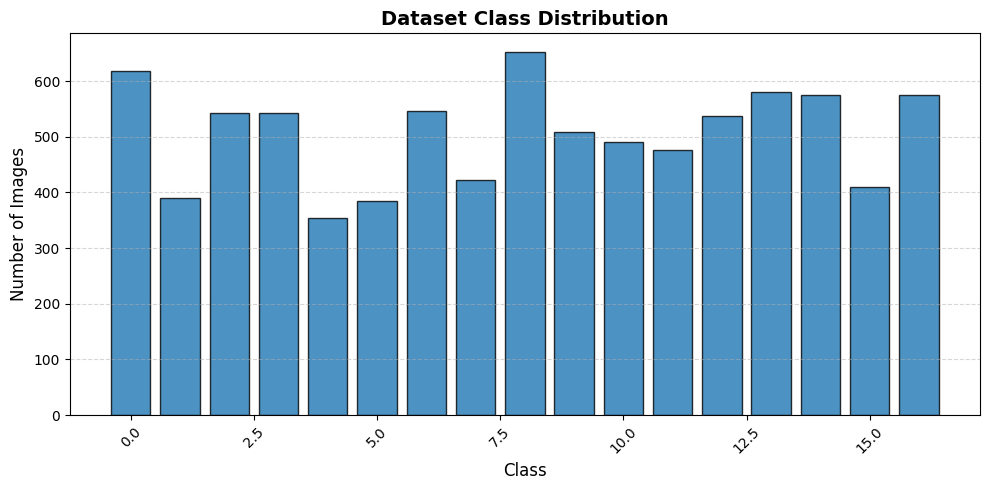

In [35]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

# 1) Load dataset from CSV
df = pd.read_csv("cars.csv")

# 2) Count how many images belong to each class
class_counts = df['label'].value_counts().sort_index()

print("Number of images per class:")
for cls, cnt in class_counts.items():
    print(f"- Class {cls}: {cnt} images")

# 3) Compute number of distinct classes
num_classes = len(class_counts)
print(f"\nTotal detected classes: {num_classes}")

# 4) Compute class weights for balancing the loss function
#    - Inverse-frequency weighting (1/frequency)
#    - Normalized around mean = 1.0
class_weights = 1.0 / torch.tensor(class_counts.values, dtype=torch.float)
class_weights = class_weights / class_weights.mean()

print("\nNormalized class weights (inverse frequency):")
for cls, w in zip(class_counts.index.tolist(), class_weights.tolist()):
    #print(f"- Class {cls}: {w:.3f}")
    pass # Pass statement to avoid indentation error


# 5) Plot class distribution as a bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    class_counts.index,
    class_counts.values,
    color="tab:blue",
    alpha=0.8,
    edgecolor="black"
)

# Add labels and title
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Dataset Class Distribution", fontsize=14, fontweight="bold")

# Style: gridlines and rotated x-axis labels
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6) Example usage in training:
# loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

## Training loop for ResNet50

This snippet defines lists for tracking training metrics across epochs, allowing results to be logged continuously or reset for new experiments.  

In [36]:
# Lists for tracking metrics across epochs
# Defined outside the loop so that after a run you can choose
# whether to reset them for a fresh experiment or keep them
# to continue logging results.
train_losses_50 = []
val_losses_50 = []
val_accuracies_50 = []

This cell trains a ResNet50 model for image classification:

- Initializes the model with the correct number of classes.  
- Uses SGD optimizer with momentum, weight decay, and a cosine annealing scheduler.  
- Applies Cross-Entropy loss (optionally weighted for imbalance).  
- Runs training and validation loops for 60 epochs, tracking loss and accuracy.  
- Saves the best model (lowest validation loss) to `model_50.pt`.  

In [37]:
import torch
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import os
from ResNet50 import ResNet50
from focal_loss import FocalLoss

# ----------------------------------------------------------
# Training script for ResNet50-based image classification
# with cosine annealing learning rate scheduler
# ----------------------------------------------------------

# Option to resume from a previously saved model checkpoint
resume_training = False
epochs = 60

# Initialize model (ResNet50 used here)
model_50 = ResNet50(num_classes=df['label'].nunique())

# Optimizer: Stochastic Gradient Descent with momentum and weight decay
opt = SGD(model_50.parameters(), lr=2*1e-2, weight_decay=1e-4)

# Scheduler: Cosine Annealing (decay LR with cosine curve)
# T_max = number of epochs for a full cosine cycle
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-3)

# Device selection (GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nCurrent device:", device, "\n")

# Loss function: Cross-Entropy with class weights to handle imbalance
#loss_fn = FocalLoss(gamma=2.0,reduction="mean")
loss_fn = torch.nn.CrossEntropyLoss()
model_50.to(device)

# Load pretrained model if requested
if resume_training and os.path.exists("model_50.pt"):
    model_50.load_state_dict(torch.load("model_50.pt", map_location=device))
    print("Model loaded from model_50.pt")
else:
    print("No model to load, training from scratch")
    # Initialize tracking lists (specific for ResNet50 results)
    train_losses_50 = []
    val_losses_50 = []
    val_accuracies_50 = []

# Training configuration
best_val = float("inf")  # Track best validation loss

# ----------------------------------------------------------
# Training and validation loop
# ----------------------------------------------------------
for epoch in range(epochs):
    model_50.train()
    running_loss = 0.0
    print(f"Epoch: {epoch+1}")
    iterator = tqdm(train_dataloader)

    # Training loop
    for batch_x, batch_y in iterator:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()

        # Forward pass
        y_pred = model_50(batch_x)
        loss = loss_fn(y_pred, batch_y)

        # Backward pass
        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()
        iterator.set_description(f"Train loss: {loss.detach().cpu().numpy():.4f}")

    # Average training loss
    avg_train_loss = running_loss / len(train_dataloader)
    train_losses_50.append(avg_train_loss)

    # Validation loop
    model_50.eval()
    with torch.no_grad():
        predictions, true = [], []
        running_val_loss = 0.0

        for batch_x, batch_y in tqdm(valid_dataloader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            y_pred = model_50(batch_x)

            running_val_loss += loss_fn(y_pred, batch_y).item()
            predictions.append(y_pred)
            true.append(batch_y)

        # Concatenate predictions and ground truth
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # Average validation loss
        avg_val_loss = running_val_loss / len(valid_dataloader)
        val_losses_50.append(avg_val_loss)

        # Accuracy
        _, predicted_classes = torch.max(predictions, 1)
        val_acc = (predicted_classes == true).float().mean().item()
        val_accuracies_50.append(val_acc)

        print(f"Validation loss: {avg_val_loss:.4f}, accuracy: {val_acc:.4f}")

    # Step the cosine annealing scheduler
    scheduler.step()
    print(f"Current LR: {scheduler.get_last_lr()}")

    # Save best model (based on lowest validation loss)
    if avg_val_loss < best_val:
        print("Saved Model")
        torch.save(model_50.state_dict(), "model_50.pt")
        best_val = avg_val_loss


Current device: cuda 

No model to load, training from scratch
Epoch: 1


100%|██████████| 27/27 [00:02<00:00, 12.40it/s]


Validation loss: 2.8026, accuracy: 0.0843
Current LR: [0.01998698058016845]
Saved Model
Epoch: 2


100%|██████████| 27/27 [00:02<00:00, 12.72it/s]


Validation loss: 2.7254, accuracy: 0.1133
Current LR: [0.019947958005998596]
Saved Model
Epoch: 3


...

Validation loss: 1.4218, accuracy: 0.5572
Current LR: [0.0010520419940014025]
Epoch: 59


100%|██████████| 27/27 [00:02<00:00, 11.62it/s]


Validation loss: 1.4229, accuracy: 0.5630
Current LR: [0.0010130194198315486]
Epoch: 60


100%|██████████| 27/27 [00:02<00:00, 11.70it/s]

Validation loss: 1.4275, accuracy: 0.5561
Current LR: [0.001]


## Evaluation for ResNet50

This cell defines and applies an evaluation pipeline for trained models:

- Defines the `evaluate_network` function to test a model on a given dataset split.  
- Collects predictions and ground truth labels over the dataloader.  
- Computes loss, accuracy, precision, recall, F1-score, and ROC-AUC.  
- Builds a confusion matrix heatmap (without numbers for clarity).  
- Plots per-class accuracy as a bar chart.  
- Loads `model_50.pt` (if available) and evaluates it on training, validation, and test sets.  

✔️ Model loaded from model_50.pt


Evaluating Training Dataset: 100%|██████████| 81/81 [00:10<00:00,  7.64it/s]



Training Dataset Metrics:
 Loss: 0.9620
 Accuracy: 0.6717
 Precision: 0.6873
 Recall: 0.6655
 F1-score: 0.6678
 ROC-AUC: 0.9694


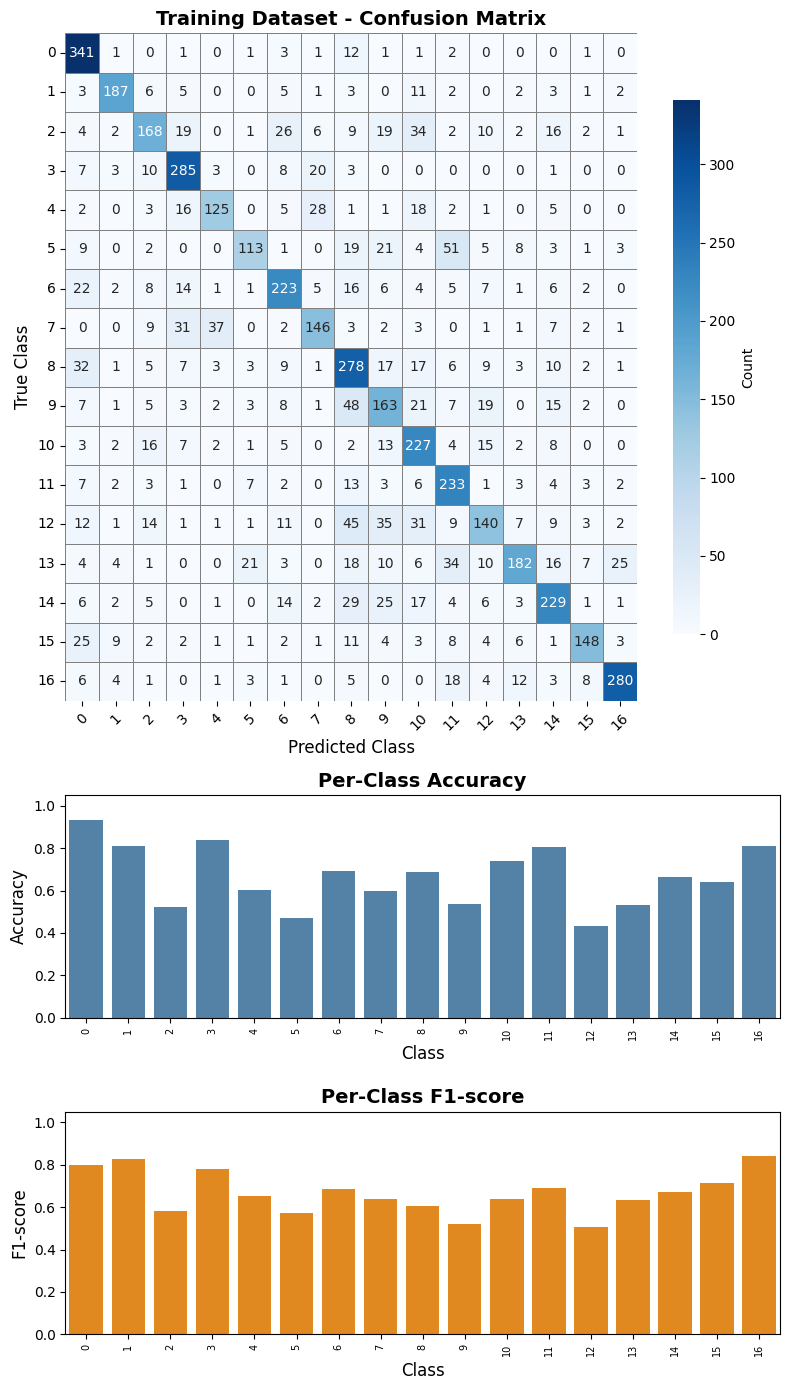

Evaluating Validation Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.43it/s]



Validation Dataset Metrics:
 Loss: 1.4221
 Accuracy: 0.5532
 Precision: 0.5989
 Recall: 0.5516
 F1-score: 0.5550
 ROC-AUC: 0.9397


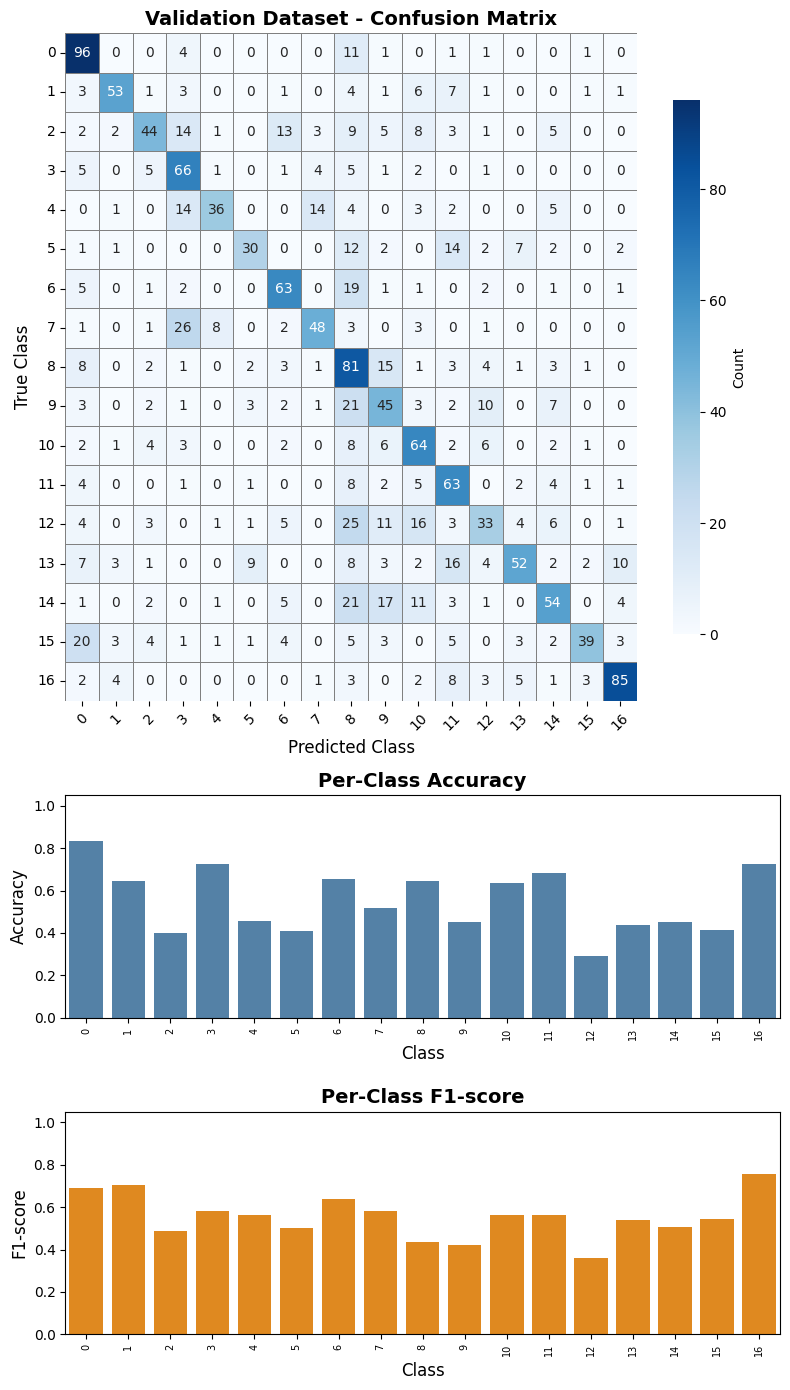

Evaluating Test Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.60it/s]



Test Dataset Metrics:
 Loss: 1.3823
 Accuracy: 0.5708
 Precision: 0.6127
 Recall: 0.5592
 F1-score: 0.5659
 ROC-AUC: 0.9410


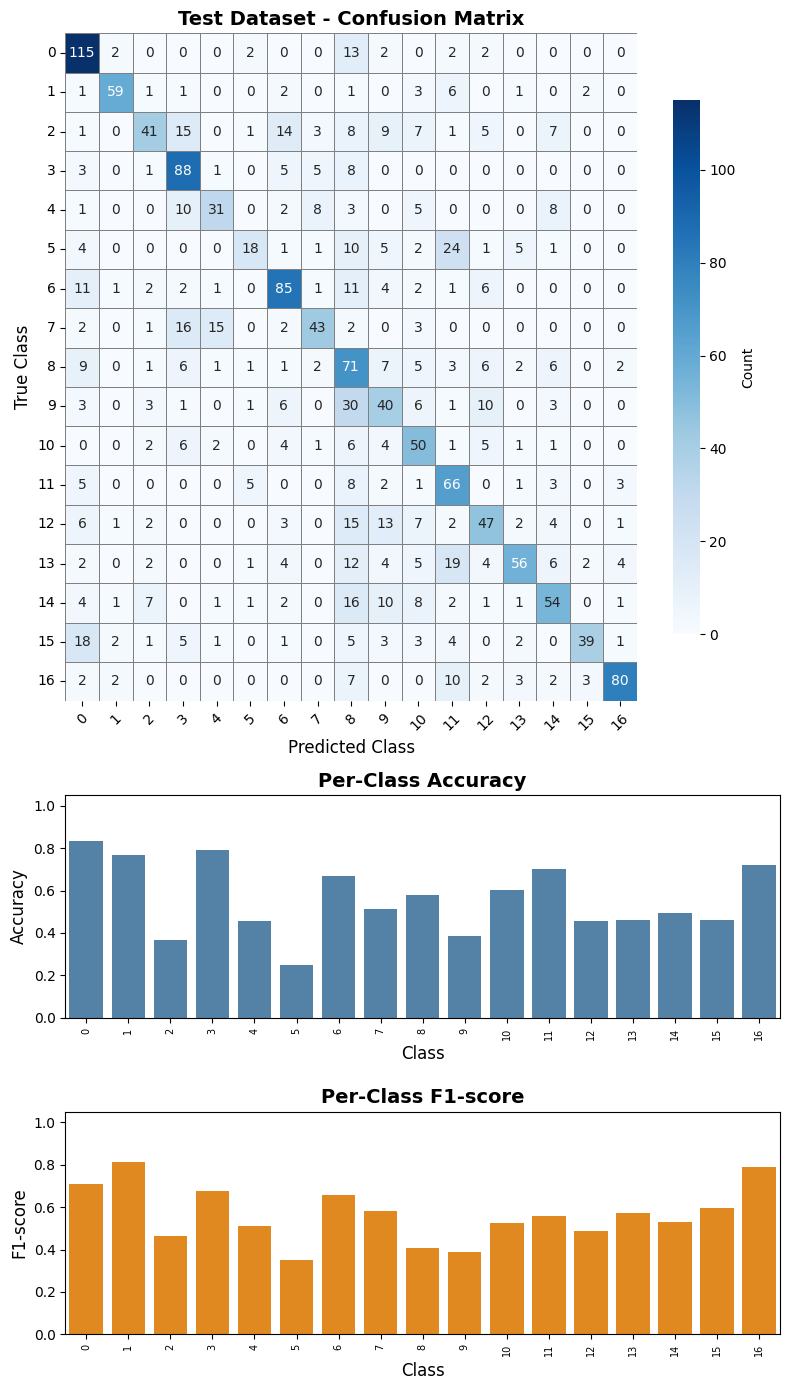

In [38]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import numpy as np
import os

# ==============================================================
# Function: evaluate_network
# --------------------------------------------------------------
def evaluate_network(dataloader, model, data_split, num_classes=10):
    model.eval()
    with torch.no_grad():
        predictions = []
        true = []

        # --- Inference over batches ---
        for batch_x, batch_y in tqdm(dataloader, desc=f"Evaluating {data_split}"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            y_pred = model(batch_x)
            predictions.append(y_pred)
            true.append(batch_y)

        # --- Concatenate all results ---
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # --- Compute loss ---
        loss = loss_fn(predictions, true).detach().cpu().item()

        # --- Convert to numpy for sklearn ---
        probs = torch.softmax(predictions, dim=1).detach().cpu().numpy()
        preds = np.argmax(probs, axis=1)
        true = true.detach().cpu().numpy()

        # --- Classification metrics ---
        accuracy = accuracy_score(true, preds)
        precision, recall, fscore, _ = precision_recall_fscore_support(true, preds, average="macro")
        auc = roc_auc_score(true, probs, multi_class="ovr")

        print(f"\n{data_split} Metrics:")
        print(f" Loss: {loss:.4f}")
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Precision: {precision:.4f}")
        print(f" Recall: {recall:.4f}")
        print(f" F1-score: {fscore:.4f}")
        print(f" ROC-AUC: {auc:.4f}")

        # --- Per-class metrics (for plots) ---
        precision_c, recall_c, f1_c, _ = precision_recall_fscore_support(true, preds, average=None, labels=np.arange(num_classes))

        # --- Confusion Matrix ---
        cm = confusion_matrix(true, preds)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,14), gridspec_kw={"height_ratios": [3, 1, 1]})

        # Heatmap Confusion Matrix WITH COLORBAR
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(num_classes),
            yticklabels=range(num_classes),
            cbar=True,
            cbar_kws={"shrink": 0.8, "label": "Count"},
            linewidths=0.5, linecolor="gray", ax=ax1
        )
        ax1.set_xlabel("Predicted Class", fontsize=12)
        ax1.set_ylabel("True Class", fontsize=12)
        ax1.set_title(f"{data_split} - Confusion Matrix", fontsize=14, fontweight="bold")
        ax1.tick_params(axis="x", rotation=45)
        ax1.tick_params(axis="y", rotation=0)

        # Per-class accuracy
        class_accuracy = cm.diagonal() / cm.sum(axis=1)
        sns.barplot(x=np.arange(num_classes), y=class_accuracy, color="steelblue", ax=ax2)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("Class", fontsize=12)
        ax2.set_ylabel("Accuracy", fontsize=12)
        ax2.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
        ax2.tick_params(axis="x", rotation=90, labelsize=7)

        # Per-class F1-score
        sns.barplot(x=np.arange(num_classes), y=f1_c, color="darkorange", ax=ax3)
        ax3.set_ylim(0, 1.05)
        ax3.set_xlabel("Class", fontsize=12)
        ax3.set_ylabel("F1-score", fontsize=12)
        ax3.set_title("Per-Class F1-score", fontsize=14, fontweight="bold")
        ax3.tick_params(axis="x", rotation=90, labelsize=7)

        plt.tight_layout()
        plt.show()


# ==============================================================
# Usage Example
# --------------------------------------------------------------
if os.path.exists("model_50.pt"):
    model_50.load_state_dict(torch.load("model_50.pt", map_location=device))
    print("✔️ Model loaded from model_50.pt")

    evaluate_network(train_dataloader, model_50, "Training Dataset", num_classes=num_classes)
    evaluate_network(valid_dataloader, model_50, "Validation Dataset", num_classes=num_classes)
    evaluate_network(test_dataloader, model_50, "Test Dataset", num_classes=num_classes)
else:
    print("No model to load")

## Training loop for ResNet18

In [39]:
# Lists for tracking metrics across epochs
train_losses_18 = []
val_losses_18 = []
val_accuracies_18 = []

In [40]:
import torch
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import os
from ResNet18 import ResNet18
from focal_loss import FocalLoss

# ----------------------------------------------------------
# Training script for ResNet18 image classification
# ----------------------------------------------------------

# Option to resume from a previously saved model_18 checkpoint
resume_training = False
epochs = 60

# Initialize model_18 (ResNet18 used here; ResNet50 is commented out)
model_18 = ResNet18(num_classes=df['label'].nunique())

# Optimizer: Stochastic Gradient Descent with momentum and weight decay
opt = SGD(model_18.parameters(), lr=2*1e-2, weight_decay=1e-4)

# Scheduler: Cosine Annealing (decay LR with cosine curve)
# T_max = number of epochs for a full cosine cycle
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-3)

# Device selection (GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nCurrent device: ", device, "\n")

# Loss function: Cross-Entropy with class weights to handle imbalance
#loss_fn = FocalLoss(gamma=2.0,reduction="mean")
loss_fn = torch.nn.CrossEntropyLoss()
model_18.to(device)

# Load pretrained model_18 if requested
if resume_training and os.path.exists("model_18.pt"):
    model_18.load_state_dict(torch.load("model_18.pt", map_location=device))
    print("Model loaded from model_18.pt")
else:
    print("No model_18 to load, training from scratch")
    # Initialize tracking lists (specific for ResNet18 results)
    train_losses_18 = []
    val_losses_18 = []
    val_accuracies_18 = []

# Training configuration
best_val = float("inf")  # Track best validation loss

# ----------------------------------------------------------
# Training and validation loop
# ----------------------------------------------------------
for epoch in range(epochs):
    model_18.train()
    running_loss = 0.0
    print(f"Epoch: {epoch+1}")
    iterator = tqdm(train_dataloader)

    # --- Training loop ---
    for batch_x, batch_y in iterator:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()

        # Forward pass
        y_pred = model_18(batch_x)
        loss = loss_fn(y_pred, batch_y)

        # Backward pass
        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()
        iterator.set_description(f"Train loss: {loss.detach().cpu().numpy():.4f}")

    # Compute average training loss
    avg_train_loss = running_loss / len(train_dataloader)
    train_losses_18.append(avg_train_loss)

    # --- Validation loop ---
    model_18.eval()
    with torch.no_grad():
        predictions, true = [], []
        running_val_loss = 0.0

        for batch_x, batch_y in tqdm(valid_dataloader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            y_pred = model_18(batch_x)

            running_val_loss += loss_fn(y_pred, batch_y).item()
            predictions.append(y_pred)
            true.append(batch_y)

        # Concatenate predictions and ground truth
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # Compute validation metrics
        avg_val_loss = running_val_loss / len(valid_dataloader)
        val_losses_18.append(avg_val_loss)

        _, predicted_classes = torch.max(predictions, 1)
        val_acc = (predicted_classes == true).float().mean().item()
        val_accuracies_18.append(val_acc)

        print(f"Validation loss: {avg_val_loss:.4f}, accuracy: {val_acc:.4f}")

    # Step the cosine annealing scheduler
    scheduler.step()
    print(f"Current LR: {scheduler.get_last_lr()}")

    # Save best model_18 (based on lowest validation loss)
    if avg_val_loss < best_val:
        print("Saved Model")
        torch.save(model_18.state_dict(), "model_18.pt")
        best_val = avg_val_loss


Current device:  cuda 

No model_18 to load, training from scratch
Epoch: 1


100%|██████████| 27/27 [00:02<00:00, 12.47it/s]


Validation loss: 2.5880, accuracy: 0.1580
Current LR: [0.01998698058016845]
Saved Model
Epoch: 2


100%|██████████| 27/27 [00:02<00:00, 12.31it/s]


Validation loss: 2.4877, accuracy: 0.1906
Current LR: [0.019947958005998596]
Saved Model
Epoch: 3


...

Validation loss: 0.2413, accuracy: 0.9320
Current LR: [0.0010520419940014025]
Saved Model
Epoch: 59


100%|██████████| 27/27 [00:02<00:00, 11.85it/s]


Validation loss: 0.2405, accuracy: 0.9262
Current LR: [0.0010130194198315486]
Saved Model
Epoch: 60


100%|██████████| 27/27 [00:02<00:00, 11.89it/s]

Validation loss: 0.2412, accuracy: 0.9320
Current LR: [0.001]


## Evaluation for ResNet18

✔️ Model loaded from model_18.pt


Evaluating Training Dataset: 100%|██████████| 81/81 [00:10<00:00,  7.79it/s]



Training Dataset Metrics:
 Loss: 0.0103
 Accuracy: 0.9990
 Precision: 0.9990
 Recall: 0.9991
 F1-score: 0.9991
 ROC-AUC: 1.0000


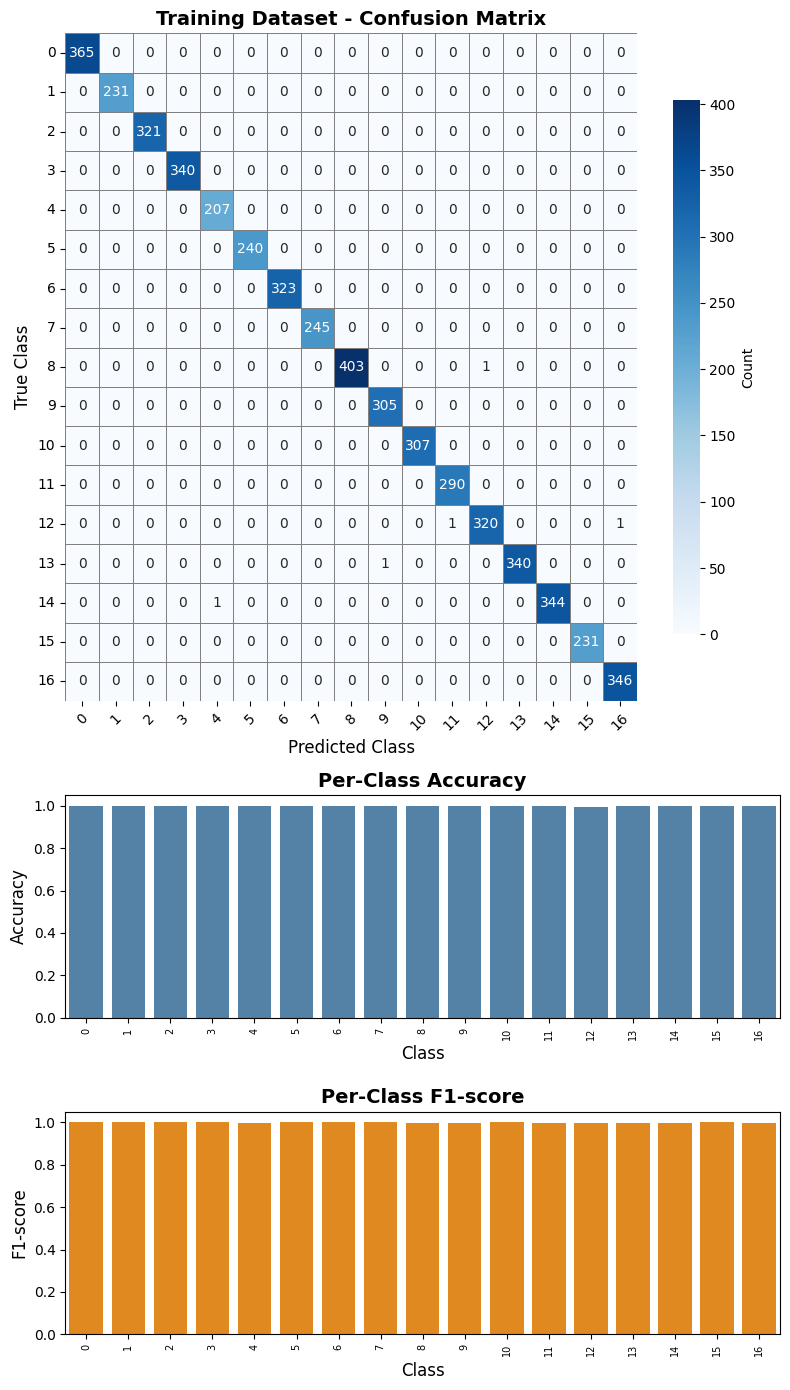

Evaluating Validation Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.57it/s]



Validation Dataset Metrics:
 Loss: 0.2405
 Accuracy: 0.9262
 Precision: 0.9314
 Recall: 0.9256
 F1-score: 0.9278
 ROC-AUC: 0.9976


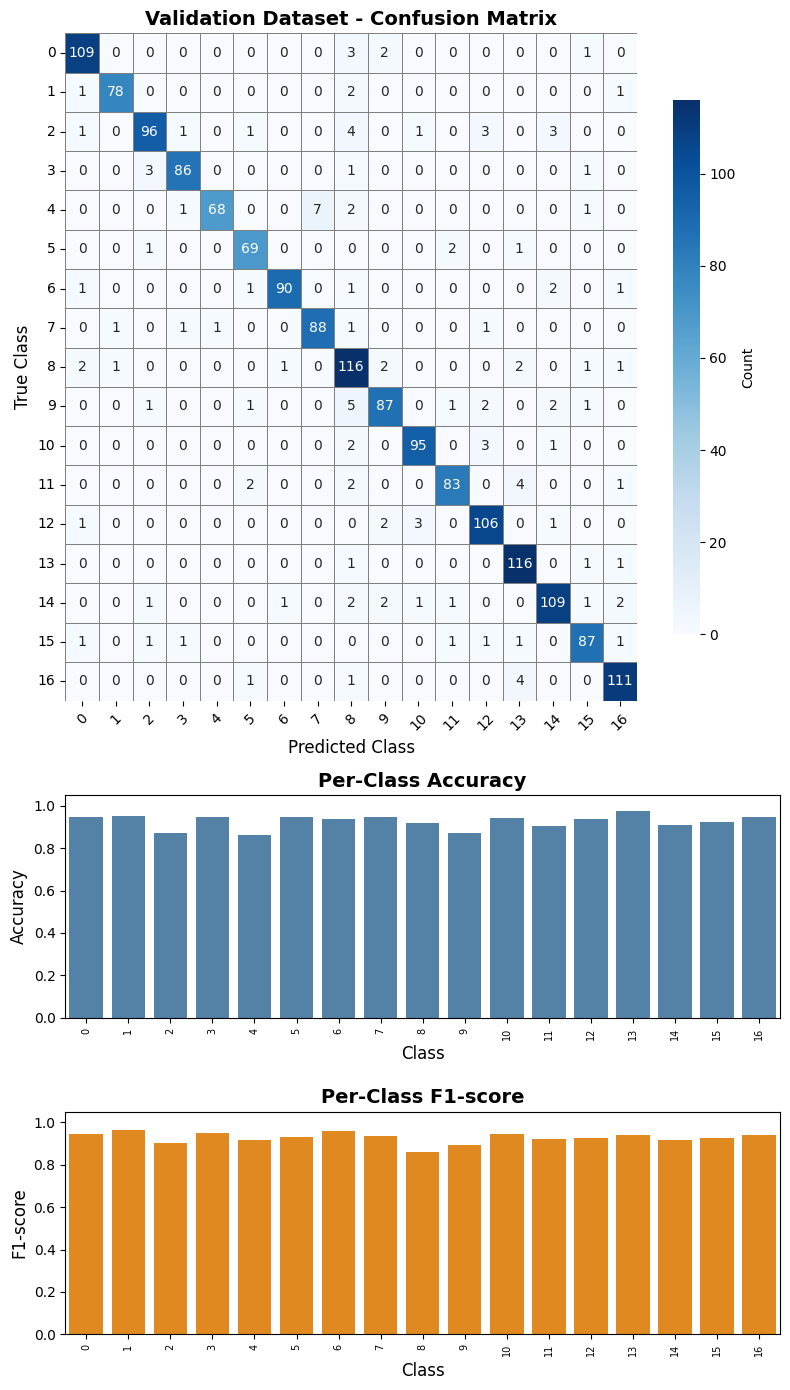

Evaluating Test Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.77it/s]



Test Dataset Metrics:
 Loss: 0.2398
 Accuracy: 0.9280
 Precision: 0.9305
 Recall: 0.9283
 F1-score: 0.9288
 ROC-AUC: 0.9975


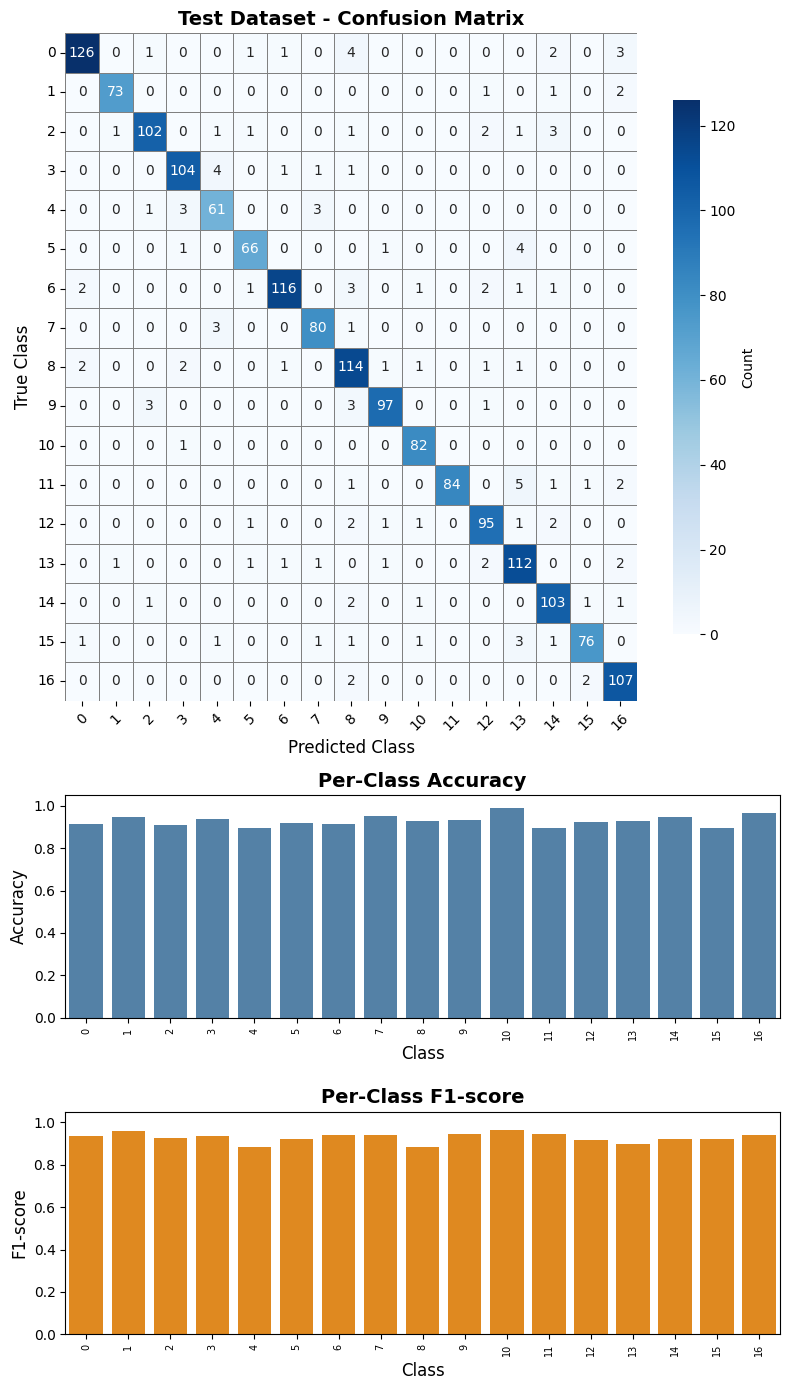

In [41]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import numpy as np
import os

# ==============================================================
# Function: evaluate_network
# --------------------------------------------------------------
def evaluate_network(dataloader, model, data_split, num_classes=10):
    model.eval()
    with torch.no_grad():
        predictions = []
        true = []

        # --- Inference over batches ---
        for batch_x, batch_y in tqdm(dataloader, desc=f"Evaluating {data_split}"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            y_pred = model(batch_x)
            predictions.append(y_pred)
            true.append(batch_y)

        # --- Concatenate all results ---
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # --- Compute loss ---
        loss = loss_fn(predictions, true).detach().cpu().item()

        # --- Convert to numpy for sklearn ---
        probs = torch.softmax(predictions, dim=1).detach().cpu().numpy()
        preds = np.argmax(probs, axis=1)
        true = true.detach().cpu().numpy()

        # --- Classification metrics ---
        accuracy = accuracy_score(true, preds)
        precision, recall, fscore, _ = precision_recall_fscore_support(true, preds, average="macro")
        auc = roc_auc_score(true, probs, multi_class="ovr")

        print(f"\n{data_split} Metrics:")
        print(f" Loss: {loss:.4f}")
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Precision: {precision:.4f}")
        print(f" Recall: {recall:.4f}")
        print(f" F1-score: {fscore:.4f}")
        print(f" ROC-AUC: {auc:.4f}")

        # --- Per-class metrics (for plots) ---
        _, _, f1_c, _ = precision_recall_fscore_support(true, preds, average=None, labels=np.arange(num_classes))

        # --- Confusion Matrix ---
        cm = confusion_matrix(true, preds)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,14), gridspec_kw={"height_ratios": [3, 1, 1]})

        # Heatmap Confusion Matrix WITH COLORBAR
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(num_classes),
            yticklabels=range(num_classes),
            cbar=True,
            cbar_kws={"shrink": 0.8, "label": "Count"},
            linewidths=0.5, linecolor="gray", ax=ax1
        )
        ax1.set_xlabel("Predicted Class", fontsize=12)
        ax1.set_ylabel("True Class", fontsize=12)
        ax1.set_title(f"{data_split} - Confusion Matrix", fontsize=14, fontweight="bold")
        ax1.tick_params(axis="x", rotation=45)
        ax1.tick_params(axis="y", rotation=0)

        # Per-class accuracy
        class_accuracy = cm.diagonal() / cm.sum(axis=1)
        sns.barplot(x=np.arange(num_classes), y=class_accuracy, color="steelblue", ax=ax2)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("Class", fontsize=12)
        ax2.set_ylabel("Accuracy", fontsize=12)
        ax2.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
        ax2.tick_params(axis="x", rotation=90, labelsize=7)

        # Per-class F1-score
        sns.barplot(x=np.arange(num_classes), y=f1_c, color="darkorange", ax=ax3)
        ax3.set_ylim(0, 1.05)
        ax3.set_xlabel("Class", fontsize=12)
        ax3.set_ylabel("F1-score", fontsize=12)
        ax3.set_title("Per-Class F1-score", fontsize=14, fontweight="bold")
        ax3.tick_params(axis="x", rotation=90, labelsize=7)

        plt.tight_layout()
        plt.show()


# ==============================================================
# Usage Example
# --------------------------------------------------------------
if os.path.exists("model_18.pt"):
    model_18.load_state_dict(torch.load("model_18.pt", map_location=device))
    print("✔️ Model loaded from model_18.pt")

    evaluate_network(train_dataloader, model_18, "Training Dataset", num_classes=num_classes)
    evaluate_network(valid_dataloader, model_18, "Validation Dataset", num_classes=num_classes)
    evaluate_network(test_dataloader, model_18, "Test Dataset", num_classes=num_classes)
else:
    print("No model_18 to load")

## Training ResNet Base

In [42]:
import torch
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import os
from ResNet_B import ResNetBase
from focal_loss import FocalLoss

# ----------------------------------------------------------
# Training script for ResNetBase image classification
# ----------------------------------------------------------

# Option to resume from a previously saved model checkpoint
resume_training = False
epochs = 60

# Initialize model_base (ResNetBase used here)
model_base = ResNetBase(num_classes=df['label'].nunique())

# Optimizer: Stochastic Gradient Descent with momentum and weight decay
opt = SGD(model_base.parameters(), lr=2*1e-2, weight_decay=1e-4)

# Scheduler: Cosine Annealing (decay LR with cosine curve)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-3)

# Device selection (GPU if available, otherwise CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nCurrent device:", device, "\n")

# Loss function: Cross-Entropy with class weights to handle imbalance
#loss_fn = FocalLoss(gamma=2.0,reduction="mean")
loss_fn = torch.nn.CrossEntropyLoss()
model_base.to(device)

# Load pretrained model if requested
if resume_training and os.path.exists("model_base.pt"):
    model_base.load_state_dict(torch.load("model_base.pt", map_location=device))
    print("Model loaded from model_base.pt")
else:
    print("No model_base to load, training from scratch")
    # Initialize tracking lists (specific for ResNetBase results)
    train_losses_base = []
    val_losses_base = []
    val_accuracies_base = []

# Training configuration
best_val = float("inf")  # Track best validation loss

# ----------------------------------------------------------
# Training and validation loop
# ----------------------------------------------------------
for epoch in range(epochs):
    model_base.train()
    running_loss = 0.0
    print(f"Epoch: {epoch+1}")
    iterator = tqdm(train_dataloader)

    # --- Training loop ---
    for batch_x, batch_y in iterator:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()

        # Forward pass
        y_pred = model_base(batch_x)
        loss = loss_fn(y_pred, batch_y)

        # Backward pass
        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()
        iterator.set_description(f"Train loss: {loss.detach().cpu().numpy():.4f}")

    # Compute average training loss
    avg_train_loss = running_loss / len(train_dataloader)
    train_losses_base.append(avg_train_loss)

    # --- Validation loop ---
    model_base.eval()
    with torch.no_grad():
        predictions, true = [], []
        running_val_loss = 0.0

        for batch_x, batch_y in tqdm(valid_dataloader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            y_pred = model_base(batch_x)

            running_val_loss += loss_fn(y_pred, batch_y).item()
            predictions.append(y_pred)
            true.append(batch_y)

        # Concatenate predictions and ground truth
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # Compute validation metrics
        avg_val_loss = running_val_loss / len(valid_dataloader)
        val_losses_base.append(avg_val_loss)

        _, predicted_classes = torch.max(predictions, 1)
        val_acc = (predicted_classes == true).float().mean().item()
        val_accuracies_base.append(val_acc)

        print(f"Validation loss: {avg_val_loss:.4f}, accuracy: {val_acc:.4f}")

    # Step the cosine annealing scheduler
    scheduler.step()
    print(f"Current LR: {scheduler.get_last_lr()}")

    # Save best model_base (based on lowest validation loss)
    if avg_val_loss < best_val:
        print("Saved Model")
        torch.save(model_base.state_dict(), "model_base.pt")
        best_val = avg_val_loss


Current device: cuda 

No model_base to load, training from scratch
Epoch: 1


100%|██████████| 27/27 [00:02<00:00, 12.84it/s]


Validation loss: 2.5663, accuracy: 0.1737
Current LR: [0.01998698058016845]
Saved Model
Epoch: 2


100%|██████████| 27/27 [00:02<00:00, 12.32it/s]


Validation loss: 2.6168, accuracy: 0.1580
Current LR: [0.019947958005998596]
Epoch: 3


...

Validation loss: 0.4221, accuracy: 0.8745
Current LR: [0.0010520419940014025]
Epoch: 59


100%|██████████| 27/27 [00:02<00:00, 11.83it/s]


Validation loss: 0.3981, accuracy: 0.8809
Current LR: [0.0010130194198315486]
Saved Model
Epoch: 60


100%|██████████| 27/27 [00:02<00:00, 11.80it/s]

Validation loss: 0.3933, accuracy: 0.8774
Current LR: [0.001]
Saved Model


## Evaluation ResNet base

✔️ Model loaded from model_base.pt


Evaluating Training Dataset: 100%|██████████| 81/81 [00:10<00:00,  7.80it/s]



Training Dataset Metrics:
 Loss: 0.1492
 Accuracy: 0.9779
 Precision: 0.9785
 Recall: 0.9780
 F1-score: 0.9782
 ROC-AUC: 0.9998


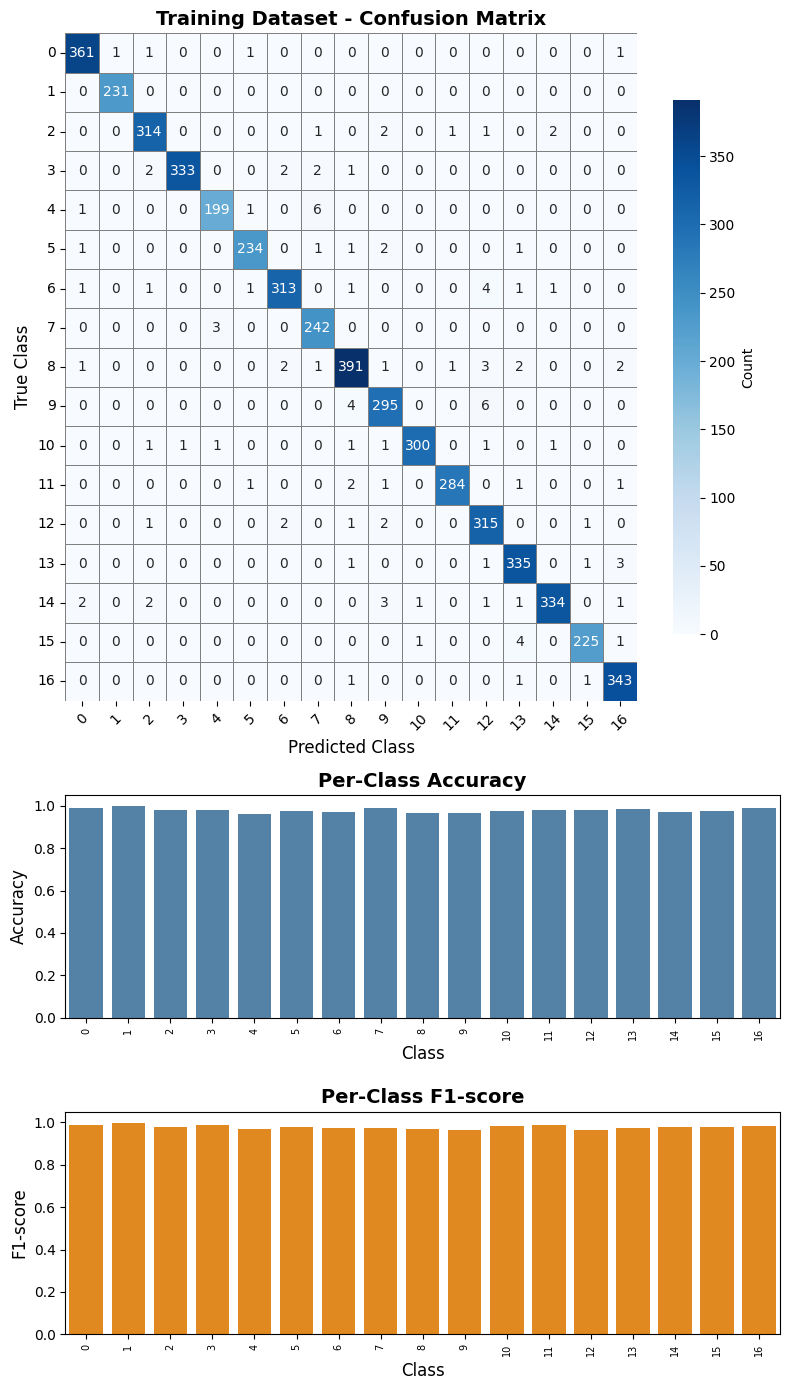

Evaluating Validation Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.11it/s]



Validation Dataset Metrics:
 Loss: 0.3937
 Accuracy: 0.8774
 Precision: 0.8838
 Recall: 0.8775
 F1-score: 0.8795
 ROC-AUC: 0.9945


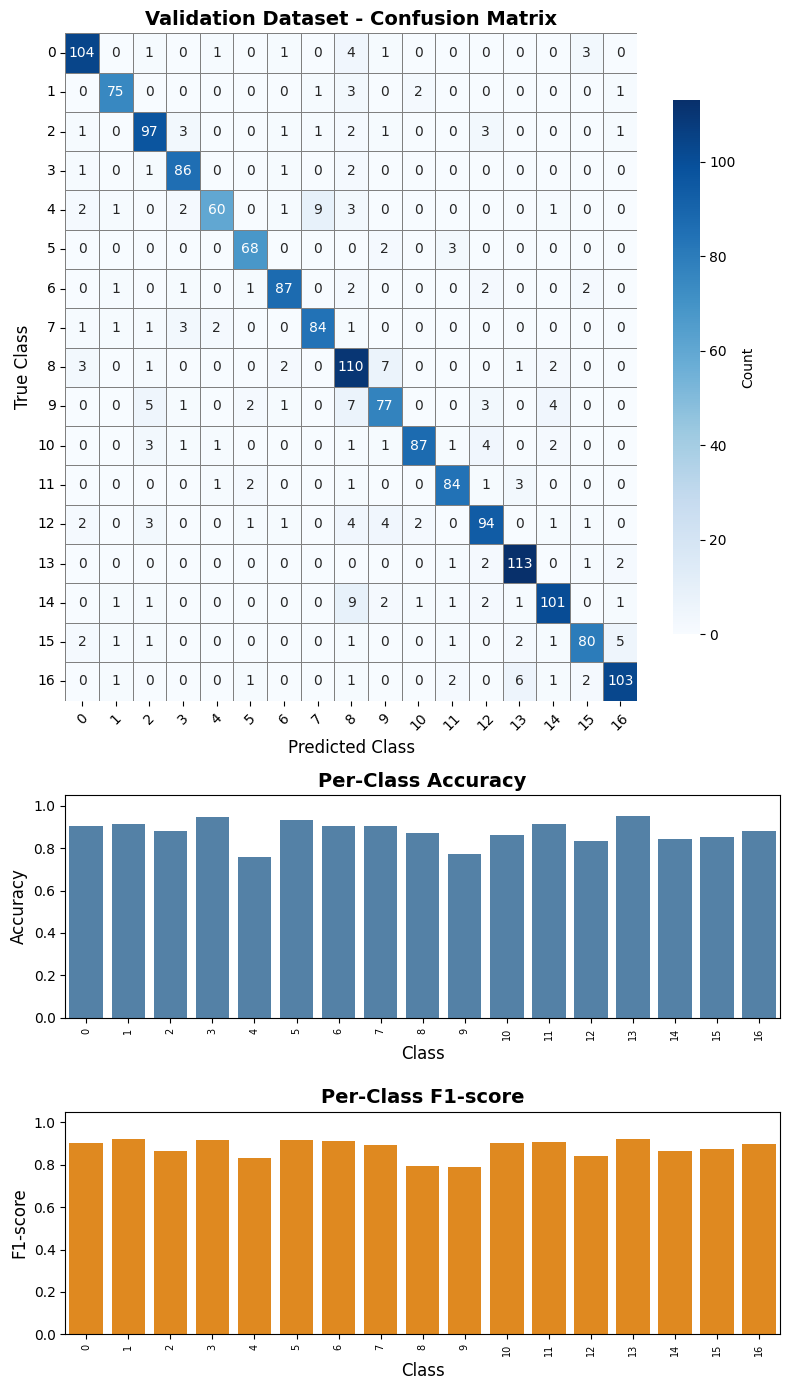

Evaluating Test Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.58it/s]



Test Dataset Metrics:
 Loss: 0.3751
 Accuracy: 0.8897
 Precision: 0.8914
 Recall: 0.8879
 F1-score: 0.8889
 ROC-AUC: 0.9952


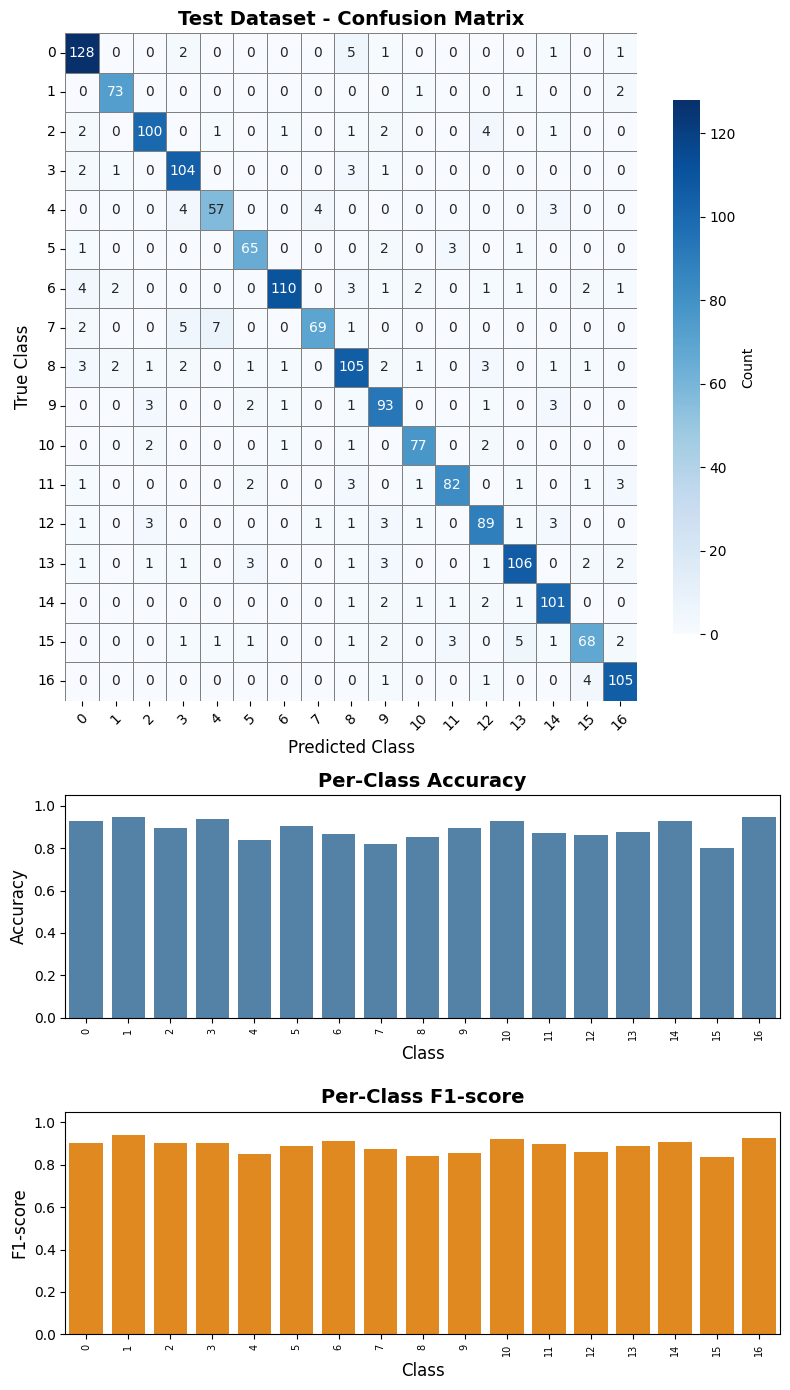

In [43]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import numpy as np
import os

# ==============================================================
# Function: evaluate_network
# --------------------------------------------------------------
def evaluate_network(dataloader, model, data_split, num_classes=10):
    model.eval()
    with torch.no_grad():
        predictions = []
        true = []

        # --- Inference over batches ---
        for batch_x, batch_y in tqdm(dataloader, desc=f"Evaluating {data_split}"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            y_pred = model(batch_x)
            predictions.append(y_pred)
            true.append(batch_y)

        # --- Concatenate all results ---
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # --- Compute loss ---
        loss = loss_fn(predictions, true).detach().cpu().item()

        # --- Convert to numpy for sklearn ---
        probs = torch.softmax(predictions, dim=1).detach().cpu().numpy()
        preds = np.argmax(probs, axis=1)
        true = true.detach().cpu().numpy()

        # --- Classification metrics ---
        accuracy = accuracy_score(true, preds)
        precision, recall, fscore, _ = precision_recall_fscore_support(true, preds, average="macro")
        auc = roc_auc_score(true, probs, multi_class="ovr")

        print(f"\n{data_split} Metrics:")
        print(f" Loss: {loss:.4f}")
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Precision: {precision:.4f}")
        print(f" Recall: {recall:.4f}")
        print(f" F1-score: {fscore:.4f}")
        print(f" ROC-AUC: {auc:.4f}")

        # --- Per-class F1 ---
        _, _, f1_c, _ = precision_recall_fscore_support(true, preds, average=None, labels=np.arange(num_classes))

        # --- Confusion Matrix ---
        cm = confusion_matrix(true, preds)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,14), gridspec_kw={"height_ratios": [3, 1, 1]})

        # Heatmap Confusion Matrix WITH COLORBAR
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(num_classes),
            yticklabels=range(num_classes),
            cbar=True,
            cbar_kws={"shrink": 0.8, "label": "Count"},
            linewidths=0.5, linecolor="gray", ax=ax1
        )
        ax1.set_xlabel("Predicted Class", fontsize=12)
        ax1.set_ylabel("True Class", fontsize=12)
        ax1.set_title(f"{data_split} - Confusion Matrix", fontsize=14, fontweight="bold")
        ax1.tick_params(axis="x", rotation=45)
        ax1.tick_params(axis="y", rotation=0)

        # Per-class accuracy
        class_accuracy = cm.diagonal() / cm.sum(axis=1)
        sns.barplot(x=np.arange(num_classes), y=class_accuracy, color="steelblue", ax=ax2)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("Class", fontsize=12)
        ax2.set_ylabel("Accuracy", fontsize=12)
        ax2.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
        ax2.tick_params(axis="x", rotation=90, labelsize=7)

        # Per-class F1-score
        sns.barplot(x=np.arange(num_classes), y=f1_c, color="darkorange", ax=ax3)
        ax3.set_ylim(0, 1.05)
        ax3.set_xlabel("Class", fontsize=12)
        ax3.set_ylabel("F1-score", fontsize=12)
        ax3.set_title("Per-Class F1-score", fontsize=14, fontweight="bold")
        ax3.tick_params(axis="x", rotation=90, labelsize=7)

        plt.tight_layout()
        plt.show()


# ==============================================================
# Usage Example
# --------------------------------------------------------------
if os.path.exists("model_base.pt"):
    model_base.load_state_dict(torch.load("model_base.pt", map_location=device))
    print("✔️ Model loaded from model_base.pt")

    evaluate_network(train_dataloader, model_base, "Training Dataset", num_classes=num_classes)
    evaluate_network(valid_dataloader, model_base, "Validation Dataset", num_classes=num_classes)
    evaluate_network(test_dataloader, model_base, "Test Dataset", num_classes=num_classes)
else:
    print("No model_base to load")

## Comperision between models:


This cell compares the training histories of ResNetBase, ResNet18, and ResNet50:  

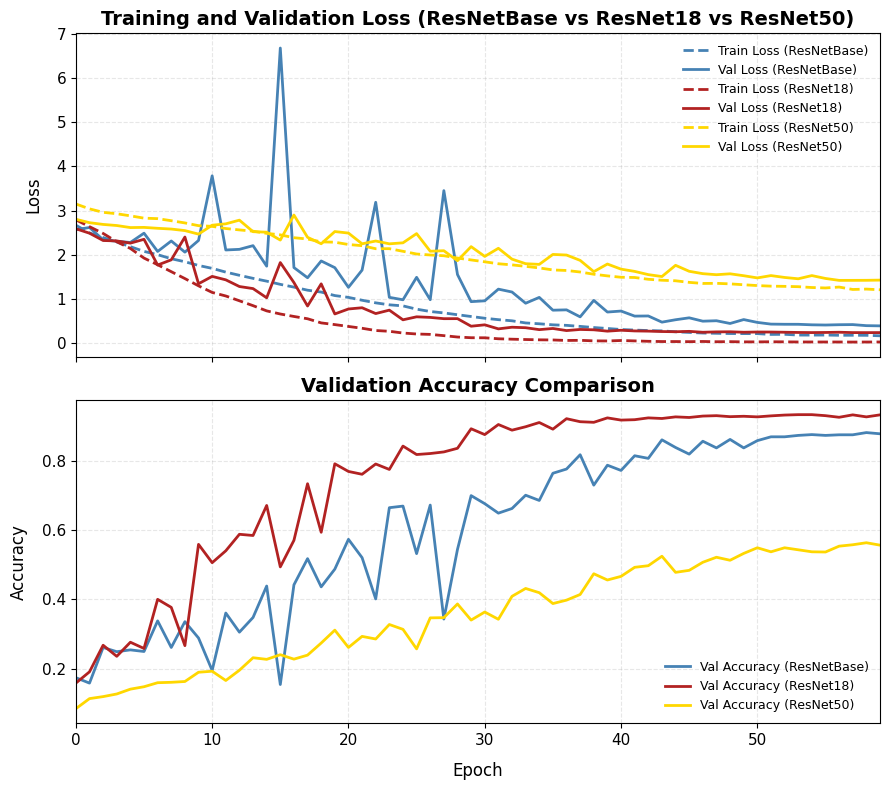

In [44]:
import matplotlib.pyplot as plt

# ==============================================================
# Compare ResNetBase, ResNet18 and ResNet50 training history
# ==============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,8), sharex=True)

# --- Training & Validation Loss ---
ax1.plot(train_losses_base, label="Train Loss (ResNetBase)", linewidth=2, linestyle="--", color="steelblue")
ax1.plot(val_losses_base,   label="Val Loss (ResNetBase)",   linewidth=2, linestyle="-",  color="steelblue")

ax1.plot(train_losses_18,   label="Train Loss (ResNet18)",   linewidth=2, linestyle="--", color="firebrick")
ax1.plot(val_losses_18,     label="Val Loss (ResNet18)",     linewidth=2, linestyle="-",  color="firebrick")

ax1.plot(train_losses_50,   label="Train Loss (ResNet50)",   linewidth=2, linestyle="--", color="gold")
ax1.plot(val_losses_50,     label="Val Loss (ResNet50)",     linewidth=2, linestyle="-",  color="gold")

ax1.set_ylabel("Loss", fontsize=12, labelpad=10)
ax1.set_title("Training and Validation Loss (ResNetBase vs ResNet18 vs ResNet50)", fontsize=14, fontweight="bold")
ax1.grid(alpha=0.3, linestyle="--")
ax1.legend(frameon=False, fontsize=9, loc="upper right")

# --- Validation Accuracy ---
ax2.plot(val_accuracies_base, label="Val Accuracy (ResNetBase)", linewidth=2, color="steelblue")
ax2.plot(val_accuracies_18,   label="Val Accuracy (ResNet18)",   linewidth=2, color="firebrick")
ax2.plot(val_accuracies_50,   label="Val Accuracy (ResNet50)",   linewidth=2, color="gold")

ax2.set_xlabel("Epoch", fontsize=12, labelpad=10)
ax2.set_ylabel("Accuracy", fontsize=12, labelpad=10)
ax2.set_title("Validation Accuracy Comparison", fontsize=14, fontweight="bold")
ax2.grid(alpha=0.3, linestyle="--")
ax2.legend(frameon=False, fontsize=9, loc="lower right")

# --- Cleanup axes and improve readability ---
for ax in [ax1, ax2]:
    ax.tick_params(axis="both", labelsize=11)
    max_epochs = max(len(train_losses_base), len(train_losses_18), len(train_losses_50))
    ax.set_xlim(0, max_epochs-1)

plt.tight_layout()
plt.show()

## Training loop for Pretrained ResNet18
This cell trains a pretrained ResNet18 (from `torchvision`) with a custom Focal Loss:

- Loads ResNet18 with pretrained ImageNet weights.  
- Replaces the final fully connected layer to match the dataset’s number of classes.  

In [45]:
train_losses_PT = []
val_losses_PT = []
val_accuracies_PT = []

In [46]:
import torch
import matplotlib.pyplot as plt
from torch.optim import SGD
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import os
import torchvision.models as models
import torch.nn as nn
from focal_loss import FocalLoss

# ----------------------------------------------------------
# Training script for ResNet18 (torchvision pretrained)
# ----------------------------------------------------------

resume_training = False
epochs = 60

# Initialize pretrained ResNet18 from torchvision
model_PT = models.resnet18(pretrained=True)

# Replace last fully connected layer with correct output size
num_ftrs = model_PT.fc.in_features
model_PT.fc = nn.Linear(num_ftrs, df['label'].nunique())

# Optimizer: Stochastic Gradient Descent
opt = SGD(model_PT.parameters(), lr=2*1e-2, weight_decay=1e-4)

# Scheduler: Cosine Annealing
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-3)

# Device selection
device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nCurrent device: ", device, "\n")

# Loss function
#loss_fn = FocalLoss(gamma=2.0,reduction="mean")
loss_fn = torch.nn.CrossEntropyLoss()
model_PT.to(device)

# Load pretrained model if requested
if resume_training and os.path.exists("model_PT.pt"):
    model_PT.load_state_dict(torch.load("model_PT.pt", map_location=device))
    print("Model loaded from model_PT.pt")
else:
    print("No model_PT to load, training from scratch")
    train_losses_PT = []
    val_losses_PT = []
    val_accuracies_PT = []

best_val = float("inf")

# ----------------------------------------------------------
# Training and validation loop
# ----------------------------------------------------------
for epoch in range(epochs):
    model_PT.train()
    running_loss = 0.0
    print(f"Epoch: {epoch+1}")
    iterator = tqdm(train_dataloader)

    # --- Training loop ---
    for batch_x, batch_y in iterator:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()

        # Forward pass
        y_pred = model_PT(batch_x)
        loss = loss_fn(y_pred, batch_y)

        # Backward pass
        opt.zero_grad()
        loss.backward()
        opt.step()

        running_loss += loss.item()
        iterator.set_description(f"Train loss: {loss.detach().cpu().numpy():.4f}")

    # Average training loss
    avg_train_loss = running_loss / len(train_dataloader)
    train_losses_PT.append(avg_train_loss)

    # --- Validation loop ---
    model_PT.eval()
    with torch.no_grad():
        predictions, true = [], []
        running_val_loss = 0.0

        for batch_x, batch_y in tqdm(valid_dataloader):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device).long()
            y_pred = model_PT(batch_x)

            running_val_loss += loss_fn(y_pred, batch_y).item()
            predictions.append(y_pred)
            true.append(batch_y)

        # Concatenate predictions and ground truth
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # Validation metrics
        avg_val_loss = running_val_loss / len(valid_dataloader)
        val_losses_PT.append(avg_val_loss)

        _, predicted_classes = torch.max(predictions, 1)
        val_acc = (predicted_classes == true).float().mean().item()
        val_accuracies_PT.append(val_acc)

        print(f"Validation loss: {avg_val_loss:.4f}, accuracy: {val_acc:.4f}")

    # Update LR
    scheduler.step()
    print(f"Current LR: {scheduler.get_last_lr()}")

    # Save best model
    if avg_val_loss < best_val:
        print("Saved Model")
        torch.save(model_PT.state_dict(), "model_PT.pt")
        best_val = avg_val_loss

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]



Current device:  cuda 

No model_PT to load, training from scratch
Epoch: 1


100%|██████████| 27/27 [00:02<00:00, 12.46it/s]


...

Validation loss: 0.0823, accuracy: 0.9768
Current LR: [0.0010520419940014025]
Epoch: 59


100%|██████████| 27/27 [00:02<00:00, 11.10it/s]


Validation loss: 0.0803, accuracy: 0.9768
Current LR: [0.0010130194198315486]
Saved Model
Epoch: 60


100%|██████████| 27/27 [00:02<00:00, 11.90it/s]

Validation loss: 0.0804, accuracy: 0.9762
Current LR: [0.001]


## Evaluation for model:PT



✔️ Model loaded from model_PT.pt


Evaluating Training Dataset: 100%|██████████| 81/81 [00:10<00:00,  7.63it/s]



Training Dataset Metrics:
 Loss: 0.0033
 Accuracy: 1.0000
 Precision: 1.0000
 Recall: 1.0000
 F1-score: 1.0000
 ROC-AUC: 1.0000


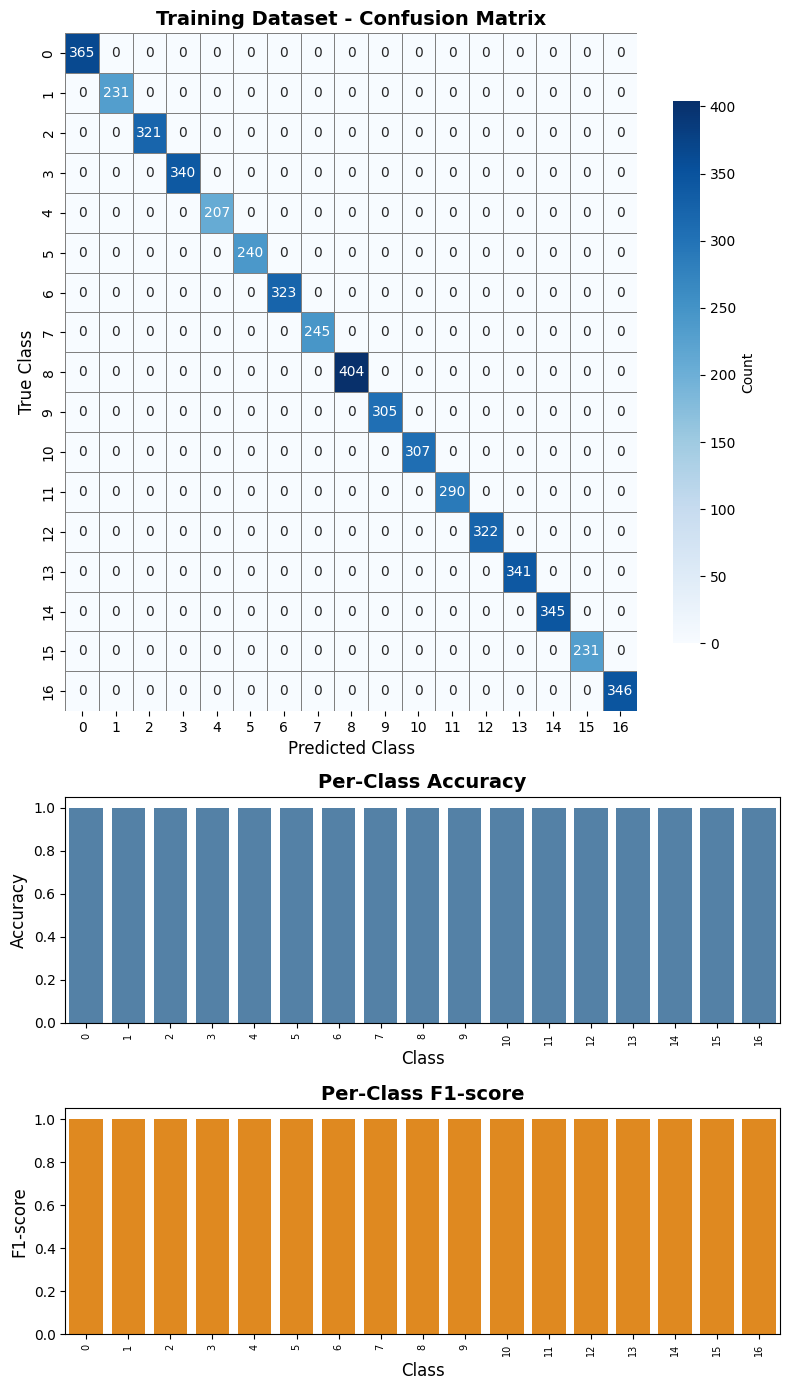

Evaluating Validation Dataset: 100%|██████████| 27/27 [00:02<00:00, 11.60it/s]



Validation Dataset Metrics:
 Loss: 0.0805
 Accuracy: 0.9768
 Precision: 0.9767
 Recall: 0.9766
 F1-score: 0.9764
 ROC-AUC: 0.9997


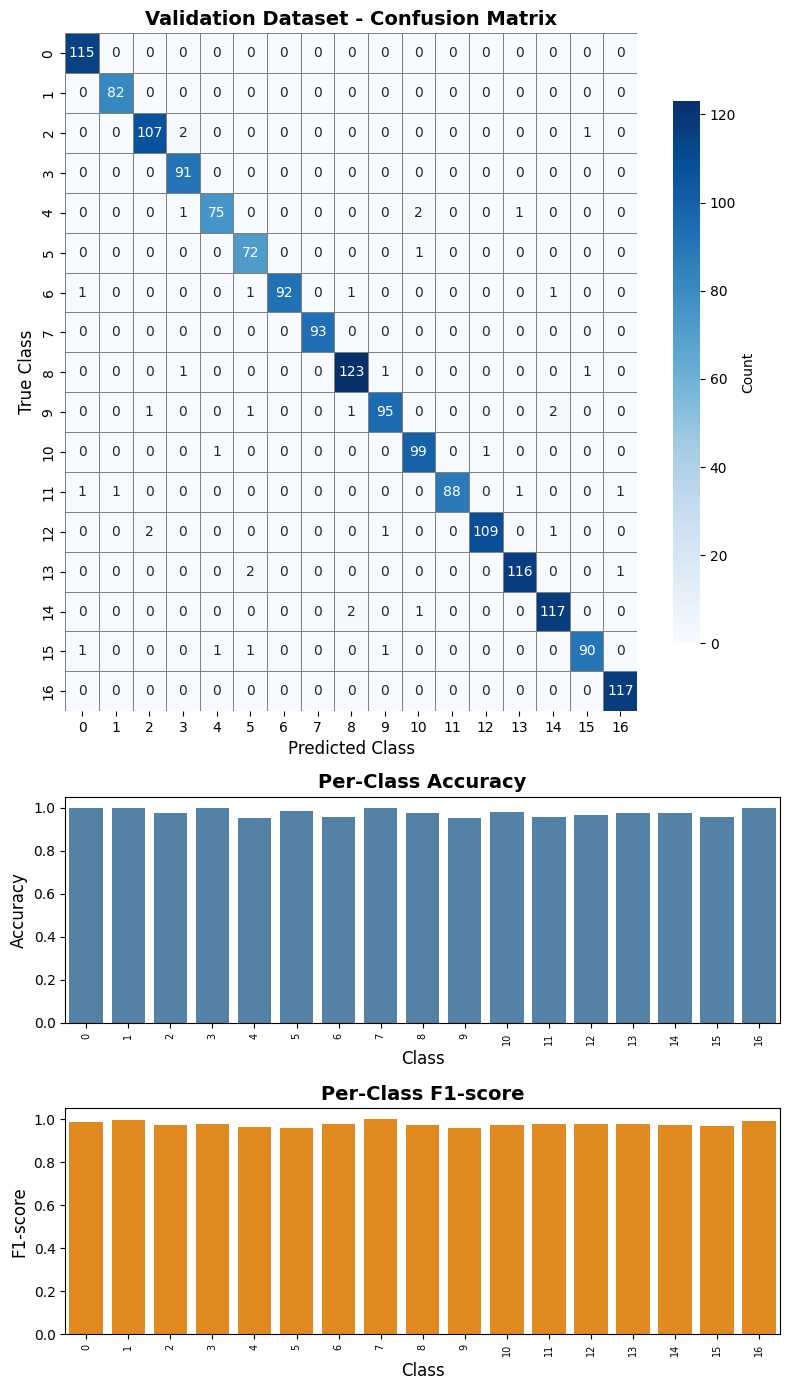

Evaluating Test Dataset: 100%|██████████| 27/27 [00:02<00:00, 12.35it/s]



Test Dataset Metrics:
 Loss: 0.0727
 Accuracy: 0.9791
 Precision: 0.9776
 Recall: 0.9795
 F1-score: 0.9784
 ROC-AUC: 0.9998


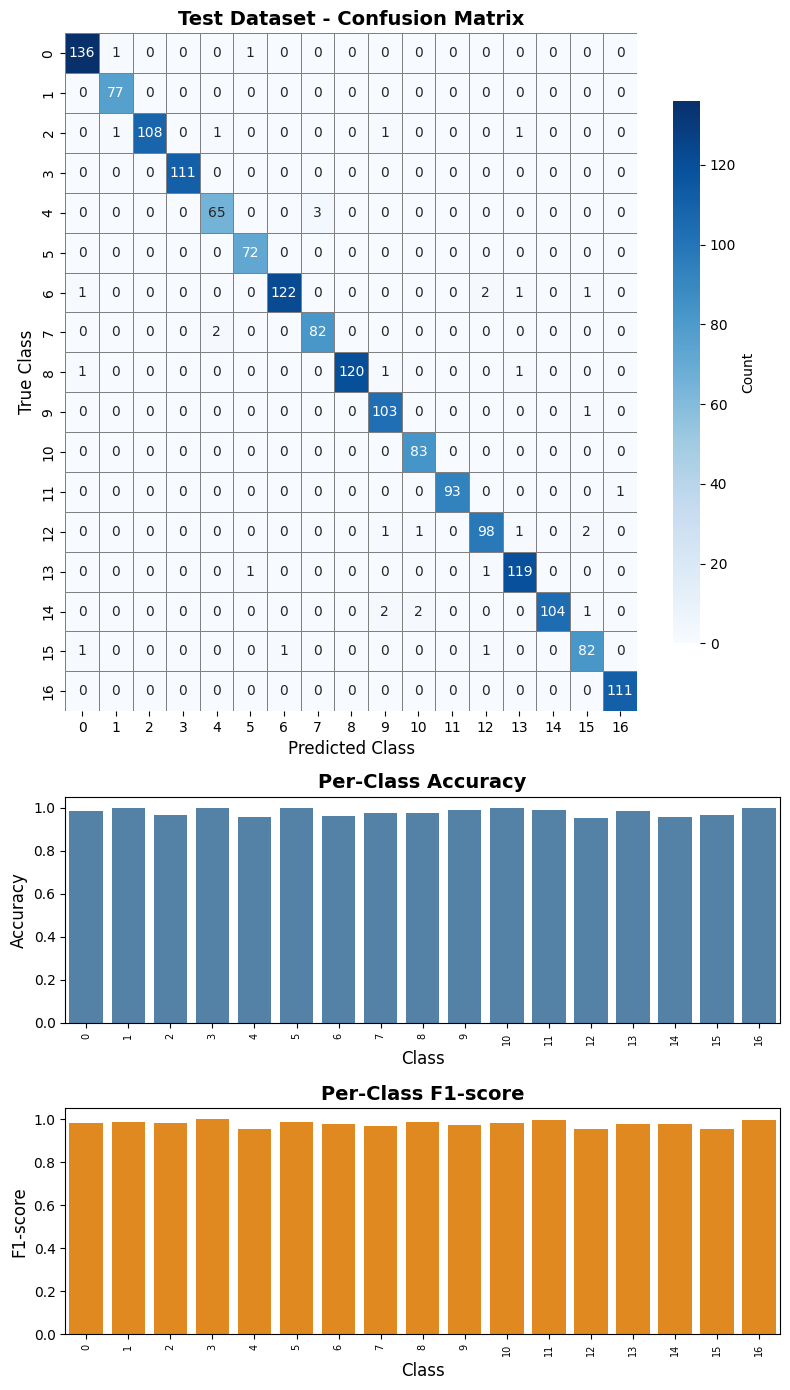

In [47]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import numpy as np
import os
import pandas as pd

# ==============================================================
# Function: evaluate_network
# --------------------------------------------------------------
def evaluate_network(dataloader, model, data_split, num_classes=10, save_path=None):
    model.eval()
    with torch.no_grad():
        predictions = []
        true = []

        # --- Inference over batches ---
        for batch_x, batch_y in tqdm(dataloader, desc=f"Evaluating {data_split}"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            y_pred = model(batch_x)
            predictions.append(y_pred)
            true.append(batch_y)

        # --- Concatenate results ---
        predictions = torch.cat(predictions, dim=0)
        true = torch.cat(true, dim=0)

        # --- Compute loss ---
        loss = loss_fn(predictions, true).detach().cpu().item()

        # --- Convert to numpy ---
        probs = torch.softmax(predictions, dim=1).detach().cpu().numpy()
        preds = np.argmax(probs, axis=1)
        true = true.detach().cpu().numpy()

        # --- Classification metrics ---
        accuracy = accuracy_score(true, preds)
        precision, recall, fscore, _ = precision_recall_fscore_support(true, preds, average="macro")
        auc = roc_auc_score(true, probs, multi_class="ovr")

        print(f"\n{data_split} Metrics:")
        print(f" Loss: {loss:.4f}")
        print(f" Accuracy: {accuracy:.4f}")
        print(f" Precision: {precision:.4f}")
        print(f" Recall: {recall:.4f}")
        print(f" F1-score: {fscore:.4f}")
        print(f" ROC-AUC: {auc:.4f}")

        # --- Per-class F1 ---
        _, _, f1_c, _ = precision_recall_fscore_support(true, preds, average=None, labels=np.arange(num_classes))

        # --- Confusion Matrix ---
        cm = confusion_matrix(true, preds)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8,14), gridspec_kw={"height_ratios": [3, 1, 1]})

        # Heatmap Confusion Matrix
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(num_classes),
            yticklabels=range(num_classes),
            cbar=True, cbar_kws={"shrink": 0.8, "label": "Count"},
            linewidths=0.5, linecolor="gray", ax=ax1
        )
        ax1.set_xlabel("Predicted Class", fontsize=12)
        ax1.set_ylabel("True Class", fontsize=12)
        ax1.set_title(f"{data_split} - Confusion Matrix", fontsize=14, fontweight="bold")

        # Per-class accuracy
        class_accuracy = cm.diagonal() / cm.sum(axis=1)
        sns.barplot(x=np.arange(num_classes), y=class_accuracy, color="steelblue", ax=ax2)
        ax2.set_ylim(0, 1.05)
        ax2.set_xlabel("Class", fontsize=12)
        ax2.set_ylabel("Accuracy", fontsize=12)
        ax2.set_title("Per-Class Accuracy", fontsize=14, fontweight="bold")
        ax2.tick_params(axis="x", rotation=90, labelsize=7)

        # Per-class F1-score
        sns.barplot(x=np.arange(num_classes), y=f1_c, color="darkorange", ax=ax3)
        ax3.set_ylim(0, 1.05)
        ax3.set_xlabel("Class", fontsize=12)
        ax3.set_ylabel("F1-score", fontsize=12)
        ax3.set_title("Per-Class F1-score", fontsize=14, fontweight="bold")
        ax3.tick_params(axis="x", rotation=90, labelsize=7)

        plt.tight_layout()
        plt.show()

        # --- Save metrics ---
        if save_path:
            results = pd.DataFrame([{
                "Dataset": data_split,
                "Loss": loss,
                "Accuracy": accuracy,
                "Precision": precision,
                "Recall": recall,
                "F1-score": fscore,
                "ROC-AUC": auc
            }])
            if not os.path.exists(save_path):
                results.to_csv(save_path, index=False)
            else:
                results.to_csv(save_path, mode="a", header=False, index=False)


# ==============================================================
# Usage Example for model_PT
# --------------------------------------------------------------
if os.path.exists("model_PT.pt"):
    model_PT.load_state_dict(torch.load("model_PT.pt", map_location=device))
    print("✔️ Model loaded from model_PT.pt")

    save_csv = "results_model_PT.csv"
    evaluate_network(train_dataloader, model_PT, "Training Dataset", num_classes=num_classes, save_path=save_csv)
    evaluate_network(valid_dataloader, model_PT, "Validation Dataset", num_classes=num_classes, save_path=save_csv)
    evaluate_network(test_dataloader, model_PT, "Test Dataset", num_classes=num_classes, save_path=save_csv)
else:
    print("No model_PT to load")

## Comparison from Pretrained ResNet18 and ResNet18 (from scratch)
This cell compares training history between ResNet18 trained from scratch and its pretrained counterpart:

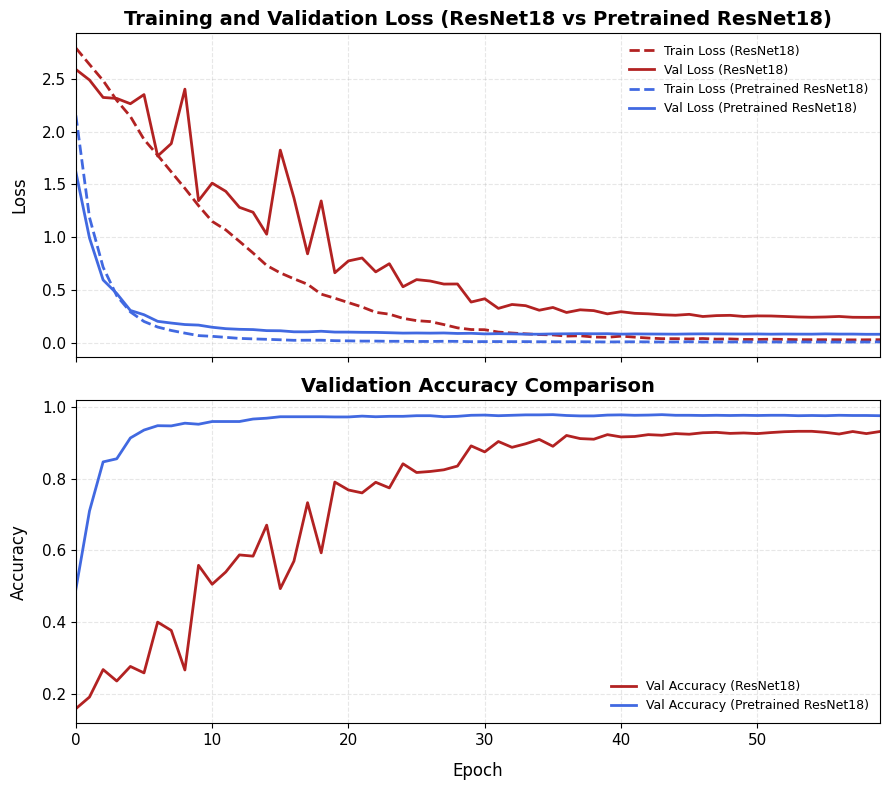

In [48]:
import matplotlib.pyplot as plt

# ==============================================================
# Compare ResNet18 (scratch) vs ResNet18 (pretrained)
# ==============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,8), sharex=True)

# --- Training & Validation Loss ---
ax1.plot(train_losses_18,   label="Train Loss (ResNet18)",   linewidth=2, linestyle="--", color="firebrick")
ax1.plot(val_losses_18,     label="Val Loss (ResNet18)",     linewidth=2, linestyle="-",  color="firebrick")

ax1.plot(train_losses_PT,   label="Train Loss (Pretrained ResNet18)", linewidth=2, linestyle="--", color="royalblue")
ax1.plot(val_losses_PT,     label="Val Loss (Pretrained ResNet18)",   linewidth=2, linestyle="-",  color="royalblue")

ax1.set_ylabel("Loss", fontsize=12, labelpad=10)
ax1.set_title("Training and Validation Loss (ResNet18 vs Pretrained ResNet18)",
              fontsize=14, fontweight="bold")
ax1.grid(alpha=0.3, linestyle="--")
ax1.legend(frameon=False, fontsize=9, loc="upper right")

# --- Validation Accuracy ---
ax2.plot(val_accuracies_18, label="Val Accuracy (ResNet18)", linewidth=2, color="firebrick")
ax2.plot(val_accuracies_PT, label="Val Accuracy (Pretrained ResNet18)", linewidth=2, color="royalblue")

ax2.set_xlabel("Epoch", fontsize=12, labelpad=10)
ax2.set_ylabel("Accuracy", fontsize=12, labelpad=10)
ax2.set_title("Validation Accuracy Comparison", fontsize=14, fontweight="bold")
ax2.grid(alpha=0.3, linestyle="--")
ax2.legend(frameon=False, fontsize=9, loc="lower right")

# --- Cleanup axes and improve readability ---
for ax in [ax1, ax2]:
    ax.tick_params(axis="both", labelsize=11)
    max_epochs = max(len(train_losses_18), len(train_losses_PT))
    ax.set_xlim(0, max_epochs-1)

plt.tight_layout()
plt.show()